In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier



In [35]:
#Метрики
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    precision_recall_fscore_support
)


#Загрузка данных

In [36]:
df_churn = pd.read_csv('train.csv')
df_churn.head()


,ClientPeriod,MonthlySpending,TotalSpent,Sex,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod,Churn
0,55,19.50,1026.35,Male,0,Yes,Yes,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,0
1,72,25.85,1872.2,Male,0,Yes,No,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),0
2,1,75.90,75.9,Male,0,No,No,Yes,No,Fiber optic,No,No,No,Yes,No,No,Month-to-month,Yes,Electronic check,1
3,32,79.30,2570,Female,1,Yes,No,Yes,Yes,Fiber optic,No,No,Yes,No,No,No,Month-to-month,No,Mailed check,0
4,60,115.25,6758.45,Female,0,Yes,Yes,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),0


Проверяем датасет на дубликаты

In [37]:
print(f"Duplicated rows: {df_churn.duplicated(keep=False).sum()}")
print(f"Duplicated rows without target: {df_churn.drop('Churn', axis=1).duplicated(keep=False).sum()}")

Duplicated rows: 28
Duplicated rows without target: 41


In [38]:
df_churn[df_churn.drop('Churn', axis=1).duplicated(keep=False)].sort_values(by=[*df_churn.columns])


,ClientPeriod,MonthlySpending,TotalSpent,Sex,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod,Churn
838,1,19.65,19.65,Female,0,No,No,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,0
1636,1,19.65,19.65,Female,0,No,No,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,0
4811,1,19.65,19.65,Female,0,No,No,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,1
3463,1,19.75,19.75,Male,0,No,No,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,0
4294,1,19.75,19.75,Male,0,No,No,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,1
3831,1,20.00,20,Male,0,No,No,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,0
1647,1,20.00,20,Male,0,No,No,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,1
594,1,20.05,20.05,Male,0,No,No,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,0
1474,1,20.05,20.05,Male,0,No,No,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,0
3735,1,20.20,20.2,Male,0,No,No,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,0


In [39]:
print(df_churn.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5282 entries, 0 to 5281
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ClientPeriod              5282 non-null   int64  
 1   MonthlySpending           5282 non-null   float64
 2   TotalSpent                5282 non-null   object 
 3   Sex                       5282 non-null   object 
 4   IsSeniorCitizen           5282 non-null   int64  
 5   HasPartner                5282 non-null   object 
 6   HasChild                  5282 non-null   object 
 7   HasPhoneService           5282 non-null   object 
 8   HasMultiplePhoneNumbers   5282 non-null   object 
 9   HasInternetService        5282 non-null   object 
 10  HasOnlineSecurityService  5282 non-null   object 
 11  HasOnlineBackup           5282 non-null   object 
 12  HasDeviceProtection       5282 non-null   object 
 13  HasTechSupportAccess      5282 non-null   object 
 14  HasOnlin

TotalSpent -  имеет тип данных "object", нужно имзенить в численный для коректной обработки данных.
После перервода в челочисленных тип, были выявлены пропуски в данных - нужно их заполнить.







In [40]:
df_churn['TotalSpent'] = pd.to_numeric(df_churn['TotalSpent'], errors='coerce', downcast=None)

In [41]:
missing = df_churn.isnull().sum().sum()
print(f"Пропущенных значений: {missing}")

Пропущенных значений: 9


In [42]:
df_churn['TotalSpent'] = df_churn['TotalSpent'].fillna(0)
missing = df_churn.isnull().sum().sum()
print(f"Пропущенных значений: {missing}")

Пропущенных значений: 0


#Анализ данных

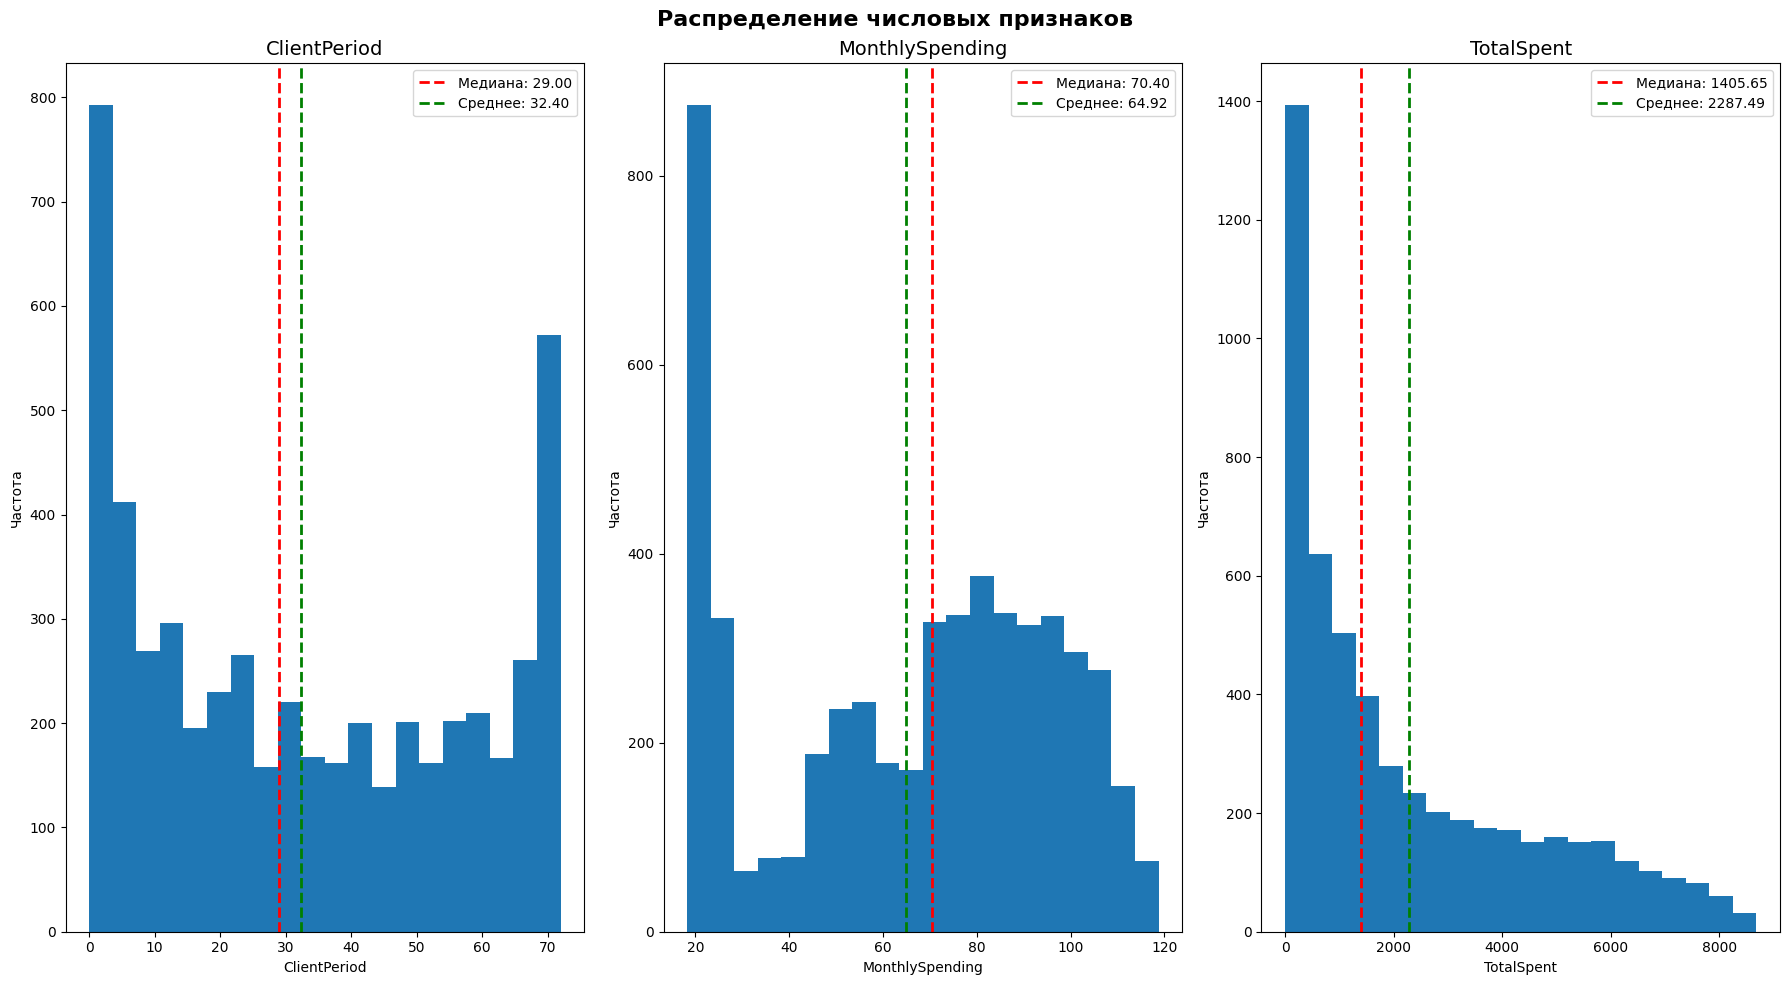

In [43]:
chl_cols = ['ClientPeriod', 'MonthlySpending', 'TotalSpent']
fig, axes = plt.subplots(1, 3, figsize=(18, 10))
fig.suptitle('Распределение числовых признаков', fontsize=16, fontweight='bold')
for ax, col in zip(axes.flatten(), chl_cols):
    ax.hist(df_churn[col], bins=20)

    median = df_churn[col].median()
    mean = df_churn[col].mean()

    ax.axvline(median, color='red', linestyle='dashed', linewidth=2, label=f'Медиана: {median:.2f}')
    ax.axvline(mean, color='green', linestyle='dashed', linewidth=2, label=f'Среднее: {mean:.2f}')
    ax.legend()

    ax.set_title(col, fontsize=14)
    ax.set_xlabel(col)
    ax.set_ylabel('Частота')
plt.tight_layout()
plt.show()

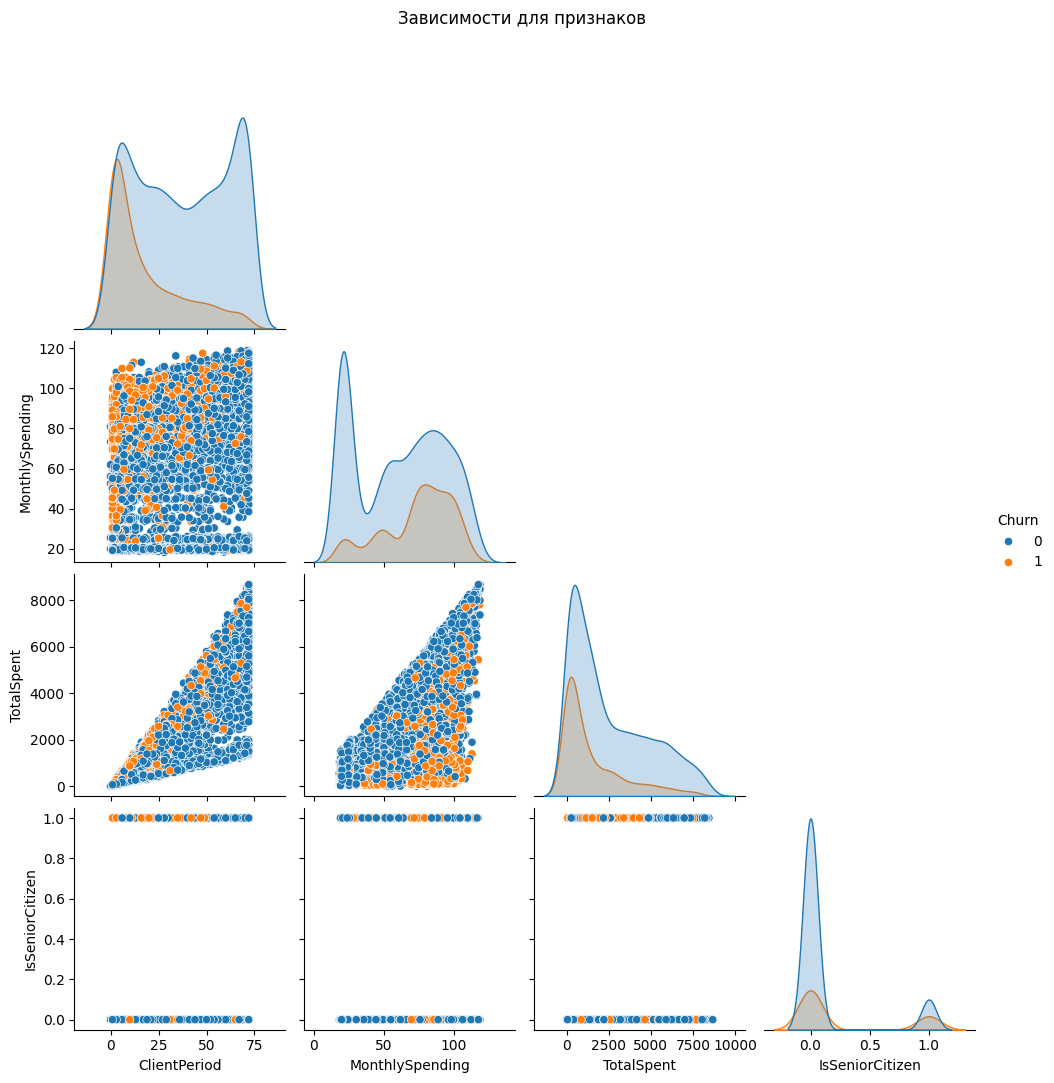

In [44]:
sns.pairplot( # матрица диаграмм рассеяния из Seaborn
data = df_churn, # данные
hue = 'Churn', # имя столбца в данных для раскраски меток
corner = True # матрица симметрична, не будем выводить лишние графики
).fig.suptitle( # настройки заголовка
'Зависимости для признаков', # заголовок
y = 1.08 # расположение
);

In [45]:
y = df_churn.Churn
class_counts = y.value_counts()
print(class_counts)
print(f"\n Соотношение: {class_counts[0] / class_counts[1]:.2f} ")

Churn
0    3898
1    1384
Name: count, dtype: int64

 Соотношение: 2.82 


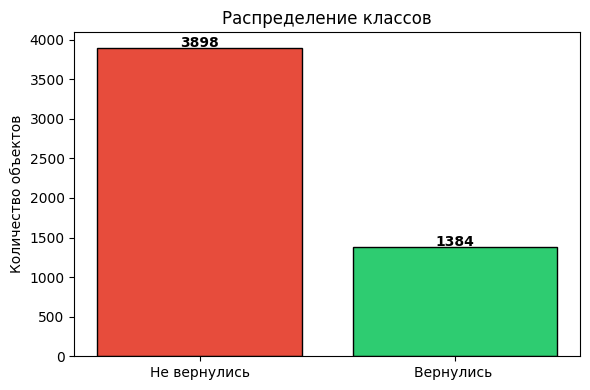

In [46]:
# Визуализируем баланс
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar([ 'Не вернулись', 'Вернулись '], class_counts.values,
       color = ['#e74c3c', '#2ecc71'], edgecolor = 'black')

ax.set_ylabel('Количество объектов')
ax.set_title('Распределение классов')
for i, v in enumerate(class_counts.values):
  ax.text(i,v+5, str(v), ha = 'center', fontweight = 'bold')
plt.tight_layout()
plt.show()

Классы  являются несбалансированными.

In [47]:
df_churn.describe()

,ClientPeriod,MonthlySpending,TotalSpent,IsSeniorCitizen,Churn
count,5282.000000,5282.000000,5282.000000,5282.000000,5282.000000
mean,32.397009,64.924754,2287.486161,0.159409,0.262022
std,24.550326,30.176464,2269.049195,0.366092,0.439776
min,0.000000,18.250000,0.000000,0.000000,0.000000
25%,9.000000,35.462500,395.725000,0.000000,0.000000
50%,29.000000,70.400000,1405.650000,0.000000,0.000000
75%,55.000000,90.050000,3795.212500,0.000000,1.000000
max,72.000000,118.750000,8684.800000,1.000000,1.000000


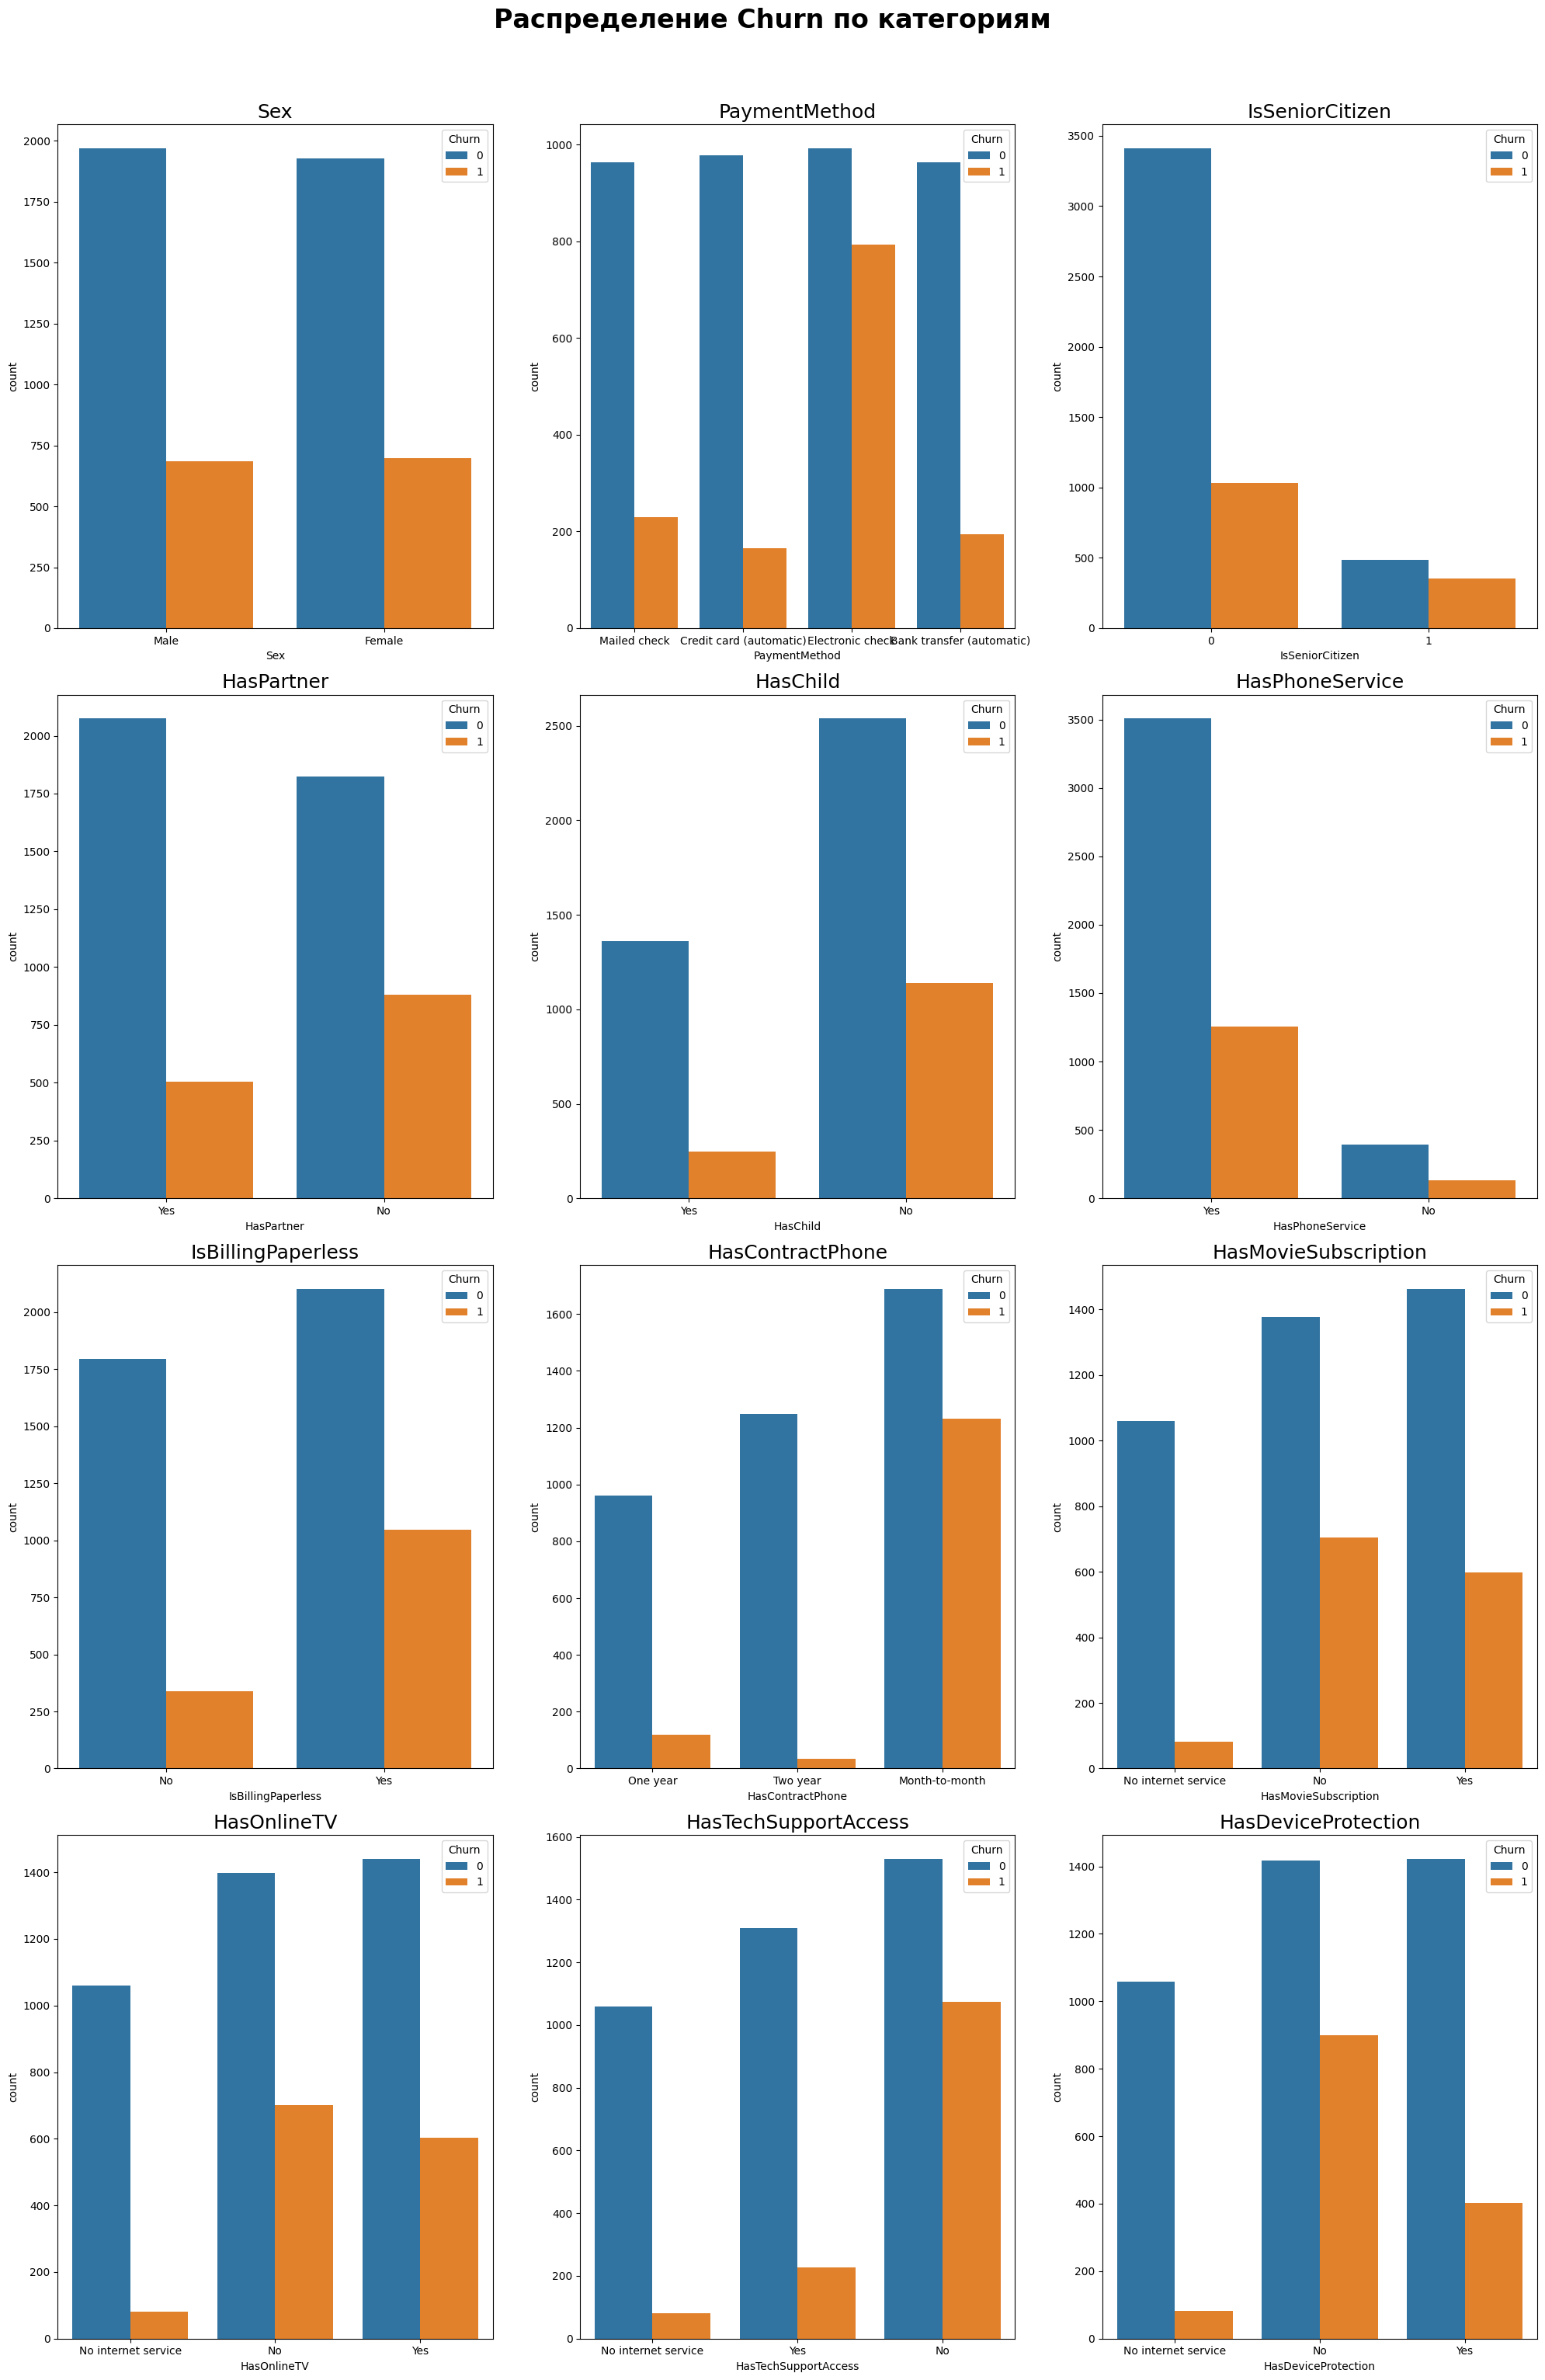

In [48]:
cat_cols = ['Sex', 'PaymentMethod', 'IsSeniorCitizen', 'HasPartner', 'HasChild',
            'HasPhoneService', 'IsBillingPaperless', 'HasContractPhone',
            'HasMovieSubscription', 'HasOnlineTV', 'HasTechSupportAccess',
            'HasDeviceProtection']

fig, axes = plt.subplots(4, 3, figsize=(20, 30))
fig.suptitle('Распределение Churn по категориям', fontsize=24, fontweight='bold', y=1.02)

for ax, col in zip(axes.flatten(), cat_cols):
    sns.countplot(data=df_churn, x=col, hue='Churn', ax=ax)
    ax.set_title(col, fontsize=18)

plt.tight_layout()
plt.show()

In [49]:
#percentage_table = df_churn['HasPartner'].value_counts(normalize=True).round(3)
#print("\nТаблица процентов:")
#print(percentage_table * 100)
#plt.pie(percentage_table.values, labels = percentage_table.index, autopct="%1.1f%%")

#plt.show()

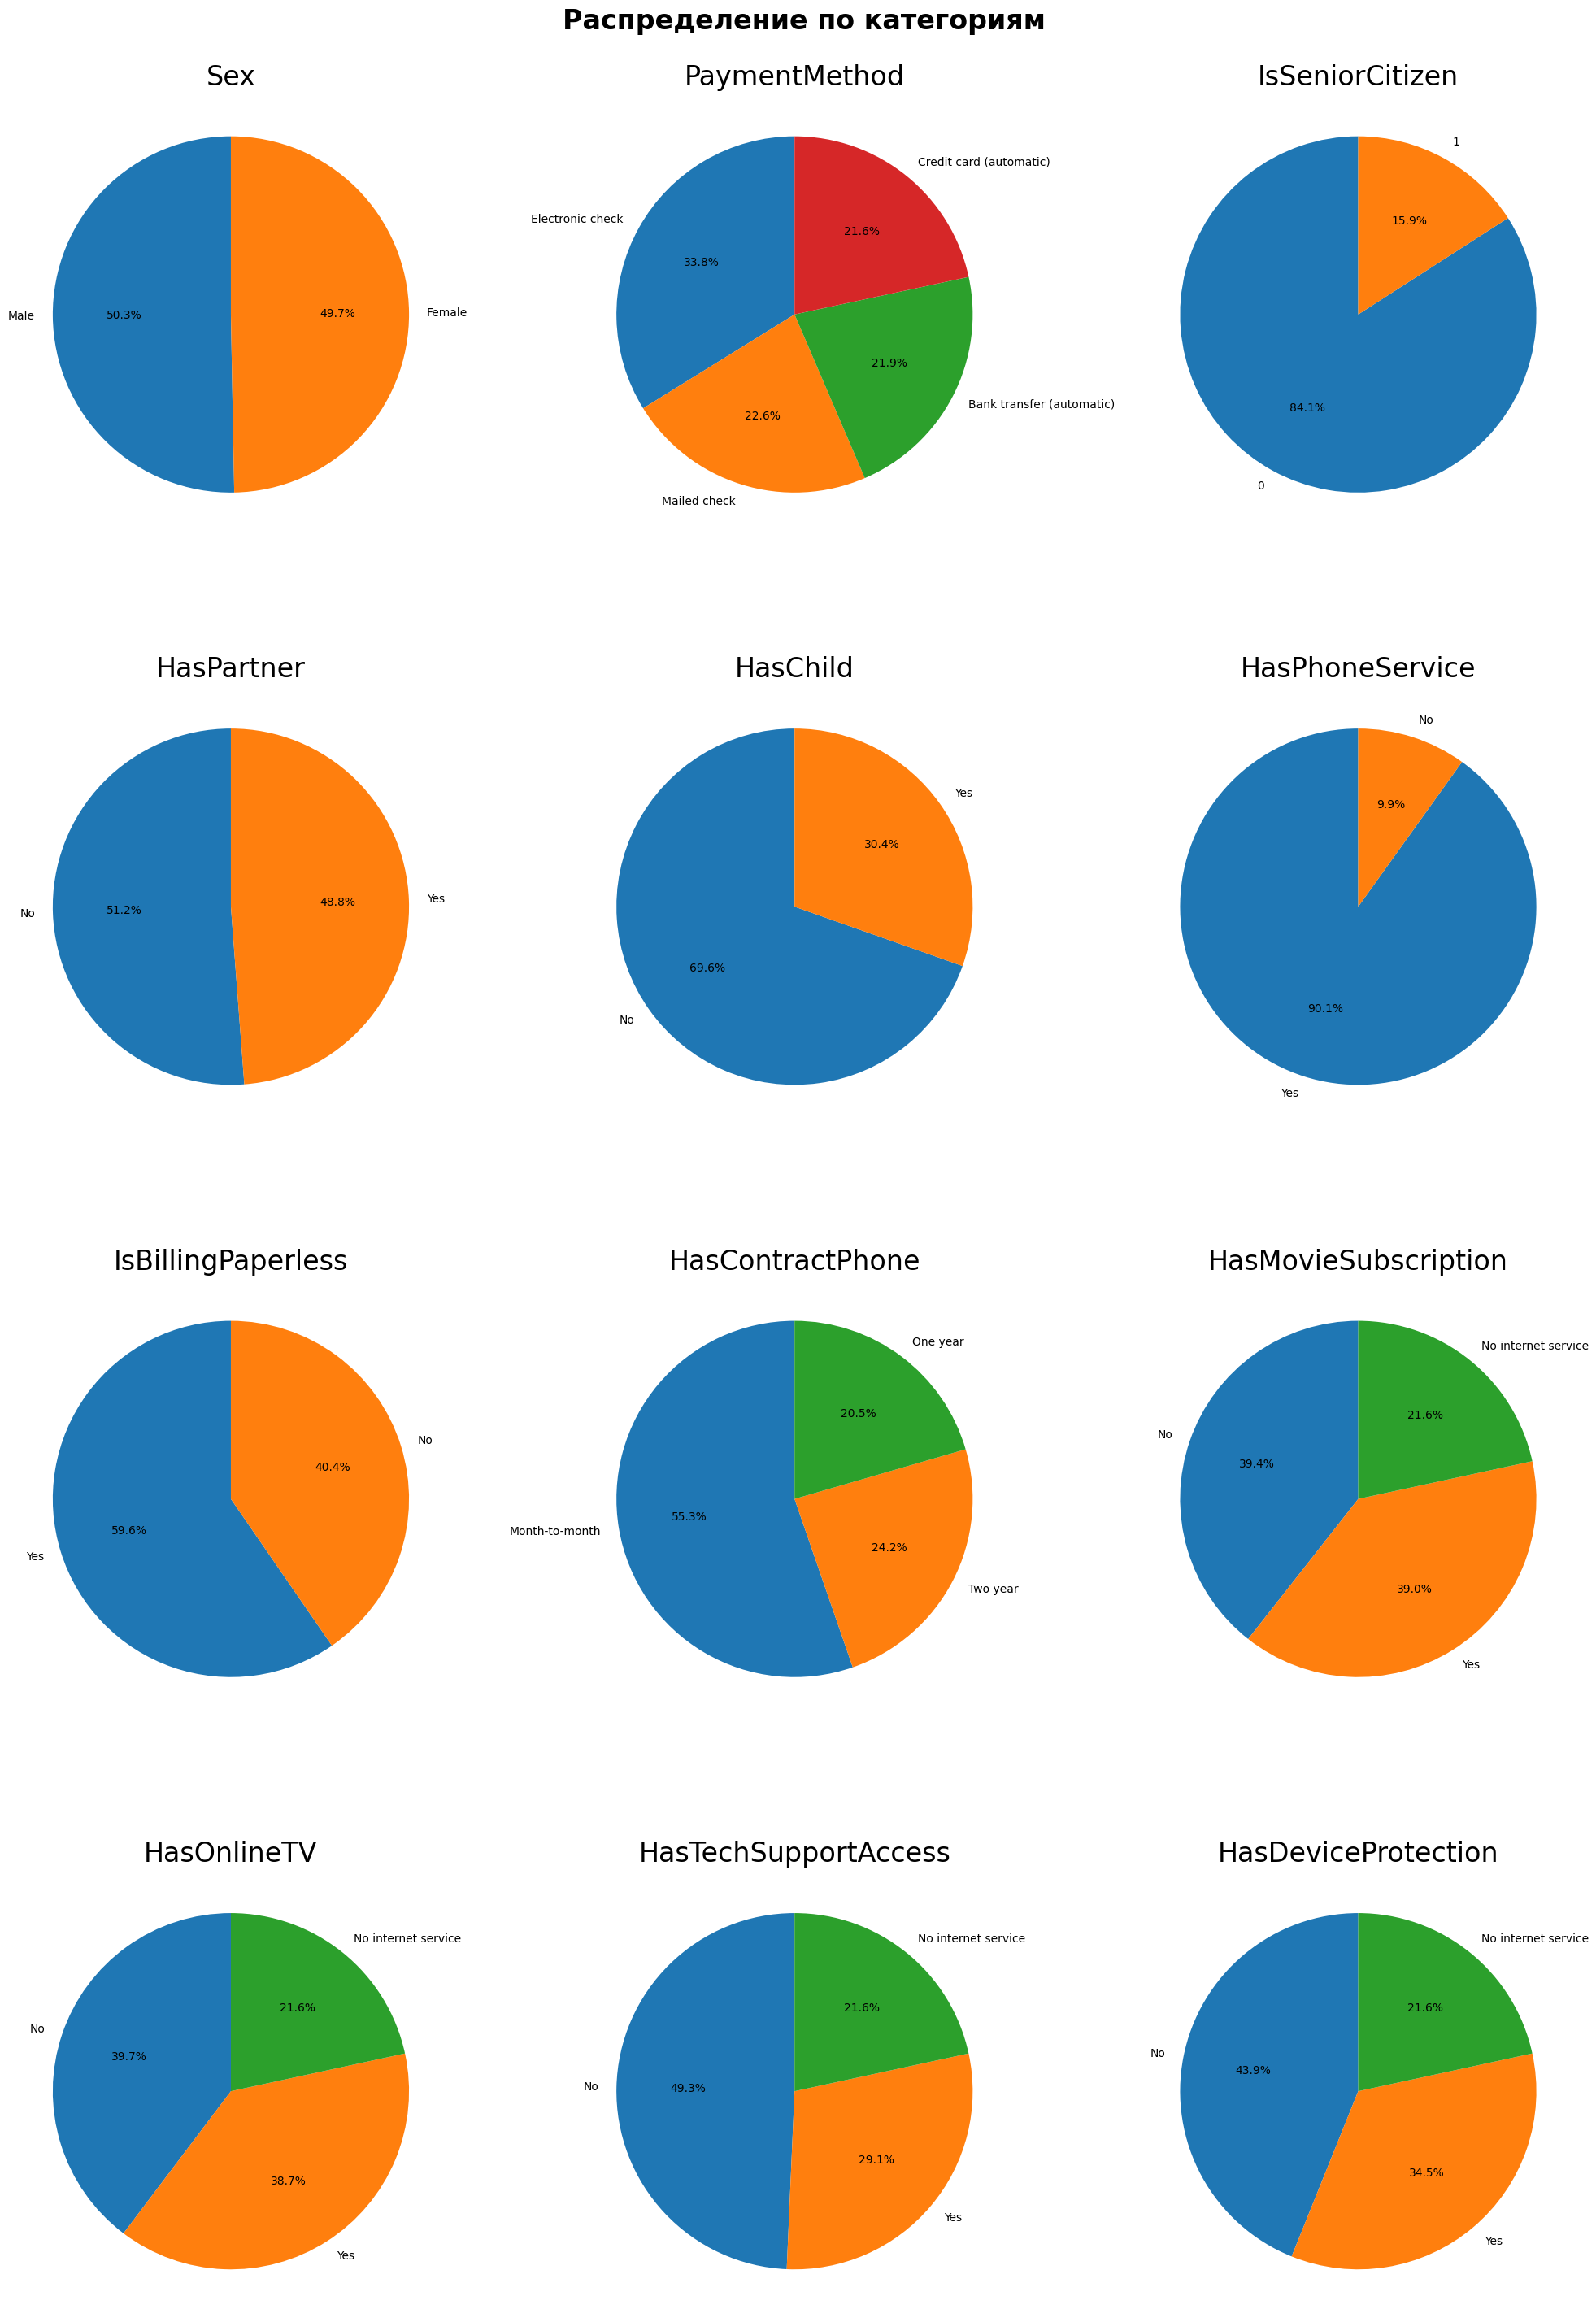

In [50]:
cat_cols = ['Sex', 'PaymentMethod', 'IsSeniorCitizen', 'HasPartner', 'HasChild', 'HasPhoneService', 'IsBillingPaperless', 'HasContractPhone', 'HasMovieSubscription', 'HasOnlineTV', 'HasTechSupportAccess', 'HasDeviceProtection']
fig, axes = plt.subplots(4, 3, figsize=(20, 30))
fig.suptitle('Распределение по категориям', fontsize=24, fontweight='bold')
for ax, col in zip(axes.flatten(), cat_cols):
    pct = df_churn[col].value_counts(normalize=True).round(3)
    ax.pie(pct.values, labels=pct.index, autopct='%1.1f%%', startangle=90)
    ax.set_title(col, fontsize=24)
plt.tight_layout()
plt.show()

# Кодирование категориальных переменных

In [51]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
binary_cols = ['Sex', 'HasPartner', 'HasChild', 'HasPhoneService', 'IsBillingPaperless']

for col in binary_cols:
    df_churn[col] = le.fit_transform(df_churn[col])
le.fit_transform(df_churn['HasChild'])[:10]

array([1, 0, 0, 0, 1, 0, 0, 0, 1, 0])

In [52]:
multi_cols = [
    'HasMultiplePhoneNumbers', 'HasInternetService', 'HasOnlineSecurityService',
    'HasOnlineBackup', 'HasDeviceProtection', 'HasTechSupportAccess',
    'HasOnlineTV', 'HasMovieSubscription', 'HasContractPhone', 'PaymentMethod'
]

df_churn = pd.get_dummies(df_churn, columns=multi_cols, drop_first=True, dtype=int)
df_churn.head()

,ClientPeriod,MonthlySpending,TotalSpent,Sex,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,IsBillingPaperless,Churn,...,HasTechSupportAccess_Yes,HasOnlineTV_No internet service,HasOnlineTV_Yes,HasMovieSubscription_No internet service,HasMovieSubscription_Yes,HasContractPhone_One year,HasContractPhone_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,55,19.50,1026.35,1,0,1,1,1,0,0,...,0,1,0,1,0,1,0,0,0,1
1,72,25.85,1872.20,1,0,1,0,1,0,0,...,0,1,0,1,0,0,1,1,0,0
2,1,75.90,75.90,1,0,0,0,1,1,1,...,1,0,0,0,0,0,0,0,1,0
3,32,79.30,2570.00,0,1,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
4,60,115.25,6758.45,0,0,1,1,1,0,0,...,1,0,1,0,1,0,1,1,0,0


#Обучение моделей

In [53]:
X = df_churn.drop(['Churn'], axis=1)
y = df_churn['Churn']
# размер тестовой выборки составит 20%
# также зададим точку отсчета для воспроизводимости
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = 0.2,
                                                    random_state = 42,
                                                    stratify = y)
print(X_train.shape)

(4225, 30)


In [54]:
#Логистическая регрессия - стандартизация, кнн и свм - нормализация
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[['TotalSpent', 'ClientPeriod', 'MonthlySpending']])
X_test_scaled = scaler.transform(X_test[['TotalSpent', 'ClientPeriod', 'MonthlySpending']])
# Проверим результат на первом признаке
print('Первый признак ДО масштабирования:')
print(f' mean={X_train.iloc[:,0].mean():.4f}, std={X_train.iloc[:,0].std():.4f}')
print("\nПервый признак ПОСЛЕ масштабирования:")
print(f"  mean={X_train_scaled[:, 0].mean():.4f}, std={X_train_scaled[:, 0].std():.4f}")

Первый признак ДО масштабирования:
 mean=32.2637, std=24.5136

Первый признак ПОСЛЕ масштабирования:
  mean=0.0000, std=1.0000


In [56]:
# Столбцы, которые были стандартизированы
scaled_cols = ['TotalSpent',  'ClientPeriod', 'MonthlySpending']

# Превращаем scaled массив обратно в DataFrame
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=scaled_cols, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=scaled_cols, index=X_test.index)
# Остальные столбцы (0/1) из X_train
X_train_rest = X_train.drop(scaled_cols, axis=1)
X_test_rest = X_test.drop(scaled_cols, axis=1)
# Объединяем
X_train_final = pd.concat([X_train_scaled_df, X_train_rest], axis=1)
X_test_final = pd.concat([X_test_scaled_df, X_test_rest], axis=1)

In [57]:
minscaler = MinMaxScaler(feature_range=(0,1))
minscaler

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False


In [58]:
X_train_minscaler = minscaler.fit_transform(X_train[['TotalSpent', 'ClientPeriod', 'MonthlySpending']])
X_test_minscaler = minscaler.transform(X_test[['TotalSpent', 'ClientPeriod', 'MonthlySpending']])

X_train_minscaler_df = pd.DataFrame(X_train_minscaler, columns=scaled_cols, index=X_train.index)
X_test_minscaler_df = pd.DataFrame(X_test_minscaler, columns=scaled_cols, index=X_test.index)
# Остальные столбцы (0/1) из X_train

X_train_final_min = pd.concat([X_train_minscaler_df, X_train_rest], axis=1)
X_test_final_min = pd.concat([X_test_minscaler_df, X_test_rest], axis=1)
minscaler.data_min_, minscaler.data_max_

(array([ 0.  ,  0.  , 18.25]), array([8672.45,   72.  ,  118.75]))

In [59]:
lr_model = LogisticRegression(C =10, max_iter=1000, random_state=42, class_weight='balanced', solver='liblinear')
lr_model.fit(X_train_final, y_train)
print("Логистическая регрессия обучена!")
print(f"Количество коэффициентов (по одному на признак): {len(lr_model.coef_[0])}")


Логистическая регрессия обучена!
Количество коэффициентов (по одному на признак): 30


In [60]:
svm_model = SVC(probability = True, kernel = 'rbf', random_state = 42, class_weight='balanced')
svm_model.fit(X_train_final_min, y_train)
print(f"SVM обучен! Kernel: {svm_model.kernel}")
print(f"Количество опорных векторов: {svm_model.support_vectors_.shape[0]}")

SVM обучен! Kernel: rbf
Количество опорных векторов: 2349


In [61]:
# n_neighbors — количество ближайших соседей для голосования
# Маленькое значение -> переобучение, большое -> недообучение
# 5 — хороший стартовый выбор
knn_model = KNeighborsClassifier(n_neighbors=20)
# KNN "запоминает" весь тренировочный датасет
# Масштабирование критически важно: без него признаки с большими значениями
# будут доминировать при вычислении расстояний
knn_model.fit(X_train_final_min,y_train)
print(f"KNN готов! Число соседей: {knn_model.n_neighbors}")

KNN готов! Число соседей: 20


In [73]:
# Получаем предсказания меток для каждой модели
y_pred_lr = lr_model.predict(X_test_final)
y_pred_svm = svm_model.predict(X_test_final_min)
y_pred_knn = knn_model.predict(X_test_final_min)
# Посмотрим на первые 10 предсказаний и истинные метки
print('Истинные метки(первые 10):         ', list(y_test[:10]))
print('Логистическая регрессия  :         ', list(y_pred_lr[:10]))
print('SVM:                               ', list(y_pred_svm[:10]))
print('KNN:                               ', list(y_pred_knn[:10]))
# Символы классов
class_names = df_churn.Churn
print(f"\n0 = {class_names[0]}, 1 = {class_names[1]}")

Истинные метки(первые 10):          [0, 0, 0, 1, 0, 0, 0, 0, 1, 0]
Логистическая регрессия  :          [np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]
SVM:                                [np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0)]
KNN:                                [np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]

0 = 0, 1 = 0


In [84]:
# Быстрое сравнение точности (accuracy) всех моделей
models = [
    ('Logistic Regression', y_pred_lr, proba_lr),
    ('SVM'      ,         y_pred_svm, proba_svm),
    ('KNN'   ,             y_pred_knn, proba_knn),
]

print('Точность(accгracy)на тесте, f-мера')
print("-"*40)
for name, preds, proba in models:

  acc = accuracy_score(y_test, preds)
  f_1 = precision_recall_fscore_support(y_test, preds, average='weighted')[2]
  print(f"  {name:<20} {acc:.4f} ({acc*100:.2f}%) {f_1:.3f}")


Точность(accгracy)на тесте, f-мера
----------------------------------------
  Logistic Regression  0.7512 (75.12%) 0.764
  SVM                  0.7521 (75.21%) 0.765
  KNN                  0.7919 (79.19%) 0.787


In [86]:
# predict_proba() возвращает матрицу [n_samples x n_classes]
# Для бинарной классификации — два столбца: [P(класс=0), P(класс=1)]
# Сумма по строке всегда равна 1.0

proba_lr  = lr_model.predict_proba(X_test_final)
proba_svm = svm_model.predict_proba(X_test_final_min)
proba_knn = knn_model.predict_proba(X_test_final_min)

print(f"Форма матрицы вероятностей: {proba_lr.shape}")
print(f"Строки = объекты ({proba_lr.shape[0]}), Столбцы = классы ({proba_lr.shape[1]})\n")

# Создаём красивую таблицу для первых 5 объектов
demo_df = pd.DataFrame({
    'Истинный класс':       list(y_test[:5].map({0: 'вернулся', 1: 'ушел'})),
    'LR P(вернулся)':             proba_lr[:5, 0].round(3),
    'LR P(ушел)':             proba_lr[:5, 1].round(3),
    'SVM P(вернулся)':            proba_svm[:5, 0].round(3),
    'SVM P(ушел)':        proba_svm[:5, 1].round(3),
    'KNN P(вернулся)':            proba_knn[:5, 0].round(3),
    'KNN P(ушел)':        proba_knn[:5, 1].round(3),
})
demo_df
# 0 = вернулся , 1 = ушел

Форма матрицы вероятностей: (1057, 2)
Строки = объекты (1057), Столбцы = классы (2)



,Истинный класс,LR P(вернулся),LR P(ушел),SVM P(вернулся),SVM P(ушел),KNN P(вернулся),KNN P(ушел)
0,вернулся,0.477,0.523,0.680,0.320,0.75,0.25
1,вернулся,0.954,0.046,0.957,0.043,1.00,0.00
2,вернулся,0.783,0.217,0.930,0.070,0.90,0.10
3,ушел,0.129,0.871,0.426,0.574,0.35,0.65
4,вернулся,0.776,0.224,0.911,0.089,0.75,0.25


In [ ]:
#from sklearn.model_selection import GridSearchCV

#Для Logistic Regression
#param_grid_lr = {'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}
#grid_lr = GridSearchCV(LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
                       #param_grid_lr, cv=5, scoring='f1')
#grid_lr.fit(X_train_final, y_train)

# Для SVM
#param_grid_svm = {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto', 0.01, 0.1]}
#grid_svm = GridSearchCV(SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42),
                        #param_grid_svm, cv=5, scoring='roc_auc')
#grid_svm.fit(X_train_final_min, y_train)

# Для KNN
#param_grid_knn = {'n_neighbors': [3, 5, 7, 11, 15, 21], 'weights': ['uniform', 'distance']}
#grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=5, scoring='roc_auc')
#grid_knn.fit(X_train_final_min, y_train)


In [87]:
roc_auc_score(y_test, proba_lr[:, 1])

0.8547995927057299

In [88]:
results = []
for name, preds,proba in models:
    results.append({
        'Модель':     name,
        'Accuracy':   round(accuracy_score(y_test, preds), 4),
        'Precision':  round(precision_score(y_test, preds, average='weighted'), 4),
        'Recall':     round(recall_score(y_test, preds, average='weighted'), 4),
        'F1-score':   round(f1_score(y_test, preds, average='weighted'), 4),
        'F1-score':   round(roc_auc_score(y_test, proba[:, 1]), 4),
    })

results_df = pd.DataFrame(results).set_index('Модель')

# Подсветим лучшие значения в каждой колонке
results_df.style.highlight_max(axis=0, color='#d4edda')

,Accuracy,Precision,Recall,F1-score
Модель,,,,
Logistic Regression,0.751200,0.807600,0.751200,0.854800
SVM,0.752100,0.801500,0.752100,0.833400
KNN,0.791900,0.784200,0.791900,0.834100


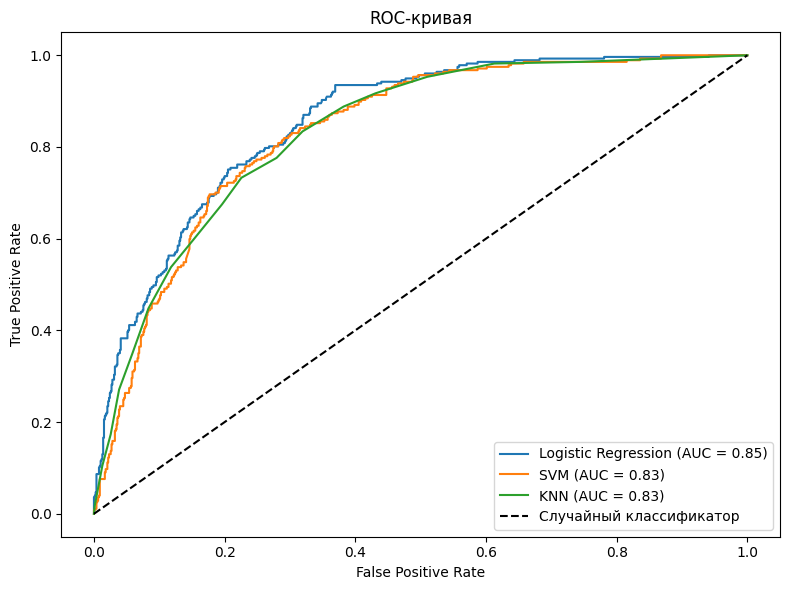

In [89]:
from sklearn.metrics import roc_curve, roc_auc_score

fig, ax = plt.subplots(figsize=(8, 6))

for name, proba in {'Logistic Regression': proba_lr, 'SVM': proba_svm, 'KNN': proba_knn}.items():
    fpr, tpr, _ = roc_curve(y_test, proba[:, 1])
    auc = roc_auc_score(y_test, proba[:, 1])
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.2f})')

ax.plot([0, 1], [0, 1], 'k--', label='Случайный классификатор')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC-кривая')
ax.legend()
plt.tight_layout()
plt.show()


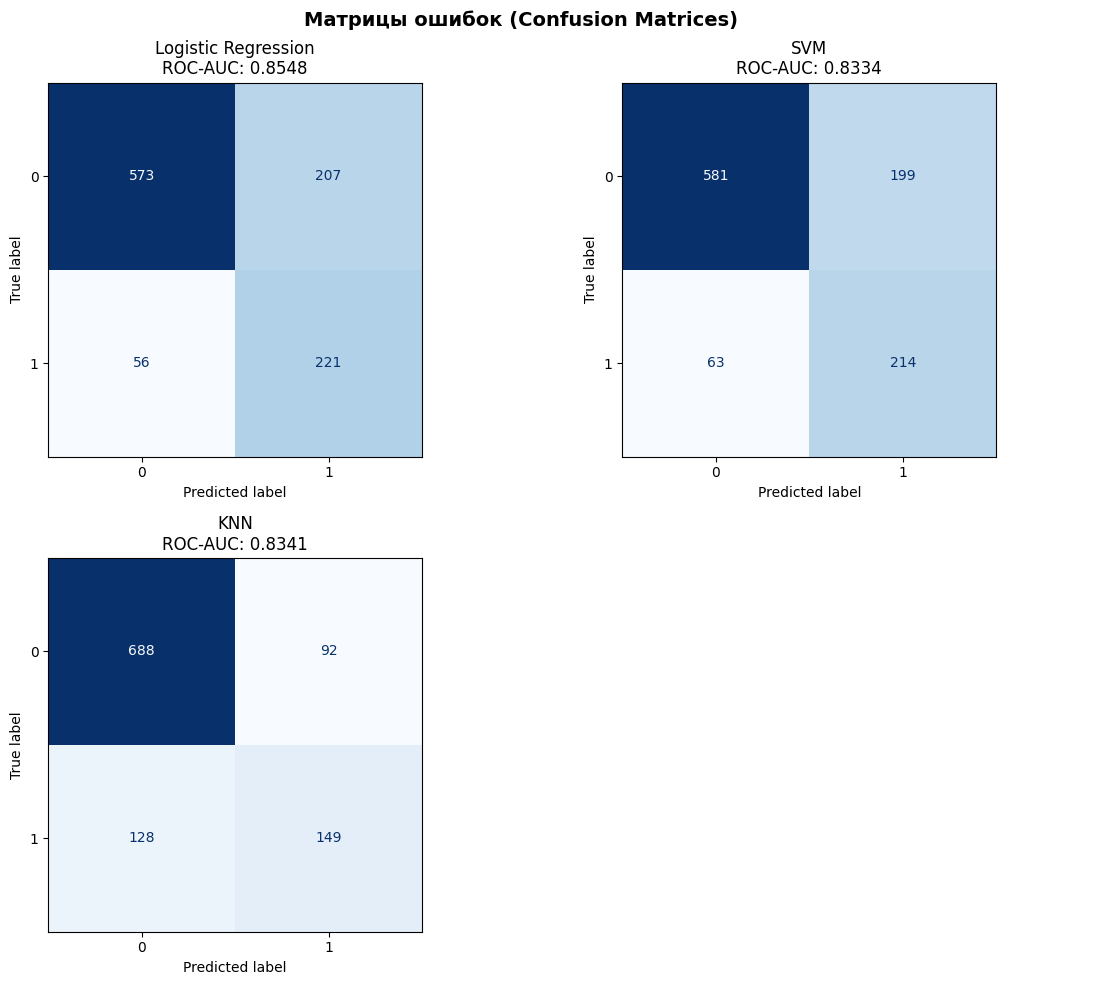

In [90]:
# Строим матрицы ошибок для всех четырёх моделей
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Матрицы ошибок (Confusion Matrices)', fontsize=14, fontweight='bold')

model_preds = [
    ('Logistic Regression', y_pred_lr, proba_lr ),
    ('SVM',                 y_pred_svm, proba_svm),
    ('KNN',                 y_pred_knn, proba_knn),
]

for ax, (name, preds, scores) in zip(axes.flatten(), model_preds):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    roc = roc_auc_score(y_test, scores[:, 1])
    ax.set_title(f'{name}\nROC-AUC: {roc:.4f}')
axes[1,1].axis('off')
plt.tight_layout()
plt.show()

Logistic Regression:
- меньше всех ошибок False Negative -  то есть меньше всех упускает клиентов которые не вернутся. 56 VS  63 в модели SVM
- больше всех False Positive (т.е  больше всех ложных тревог )

Есои цель бизнеса поймать всех клиентов, которые планируют не возвращаться, то Logistic Regression наилучший вариант

#Проверка на тестовых данных

In [92]:
df_test_data = pd.read_csv('test.csv')

In [93]:
best_model = lr_model

In [97]:
X_test = pd.read_csv('test.csv')
submission = pd.DataFrame()



# 1. LabelEncoder для бинарных столбцов
binary_cols = ['Sex', 'HasPartner', 'HasChild', 'HasPhoneService', 'IsBillingPaperless']
le = LabelEncoder()
for col in binary_cols:
    X_test[col] = le.fit_transform(X_test[col])

# 2. TotalSpent -> numeric
X_test['TotalSpent'] = pd.to_numeric(X_test['TotalSpent'], errors='coerce')
X_test['TotalSpent'] = X_test['TotalSpent'].fillna(0)

# 3. get_dummies для мультикатегориальных
multi_cols = [
    'HasMultiplePhoneNumbers', 'HasInternetService', 'HasOnlineSecurityService',
    'HasOnlineBackup', 'HasDeviceProtection', 'HasTechSupportAccess',
    'HasOnlineTV', 'HasMovieSubscription', 'HasContractPhone', 'PaymentMethod'
]
X_test = pd.get_dummies(X_test, columns=multi_cols, drop_first=True, dtype=int)

# 4. Выровнять столбцы — добавить отсутствующие, убрать лишние
train_cols = X_train_final.columns
for c in train_cols:
    if c not in X_test.columns:
        X_test[c] = 0
X_test = X_test[train_cols]

# 5. Масштабирование числовых
scaled_cols = ['TotalSpent', 'ClientPeriod', 'MonthlySpending']
X_test[scaled_cols] = scaler.transform(X_test[scaled_cols])

# 6. Предсказание
submission['Churn'] = lr_model.predict_proba(X_test)[:, 1]
submission.to_csv('my_submission.csv', index=False)


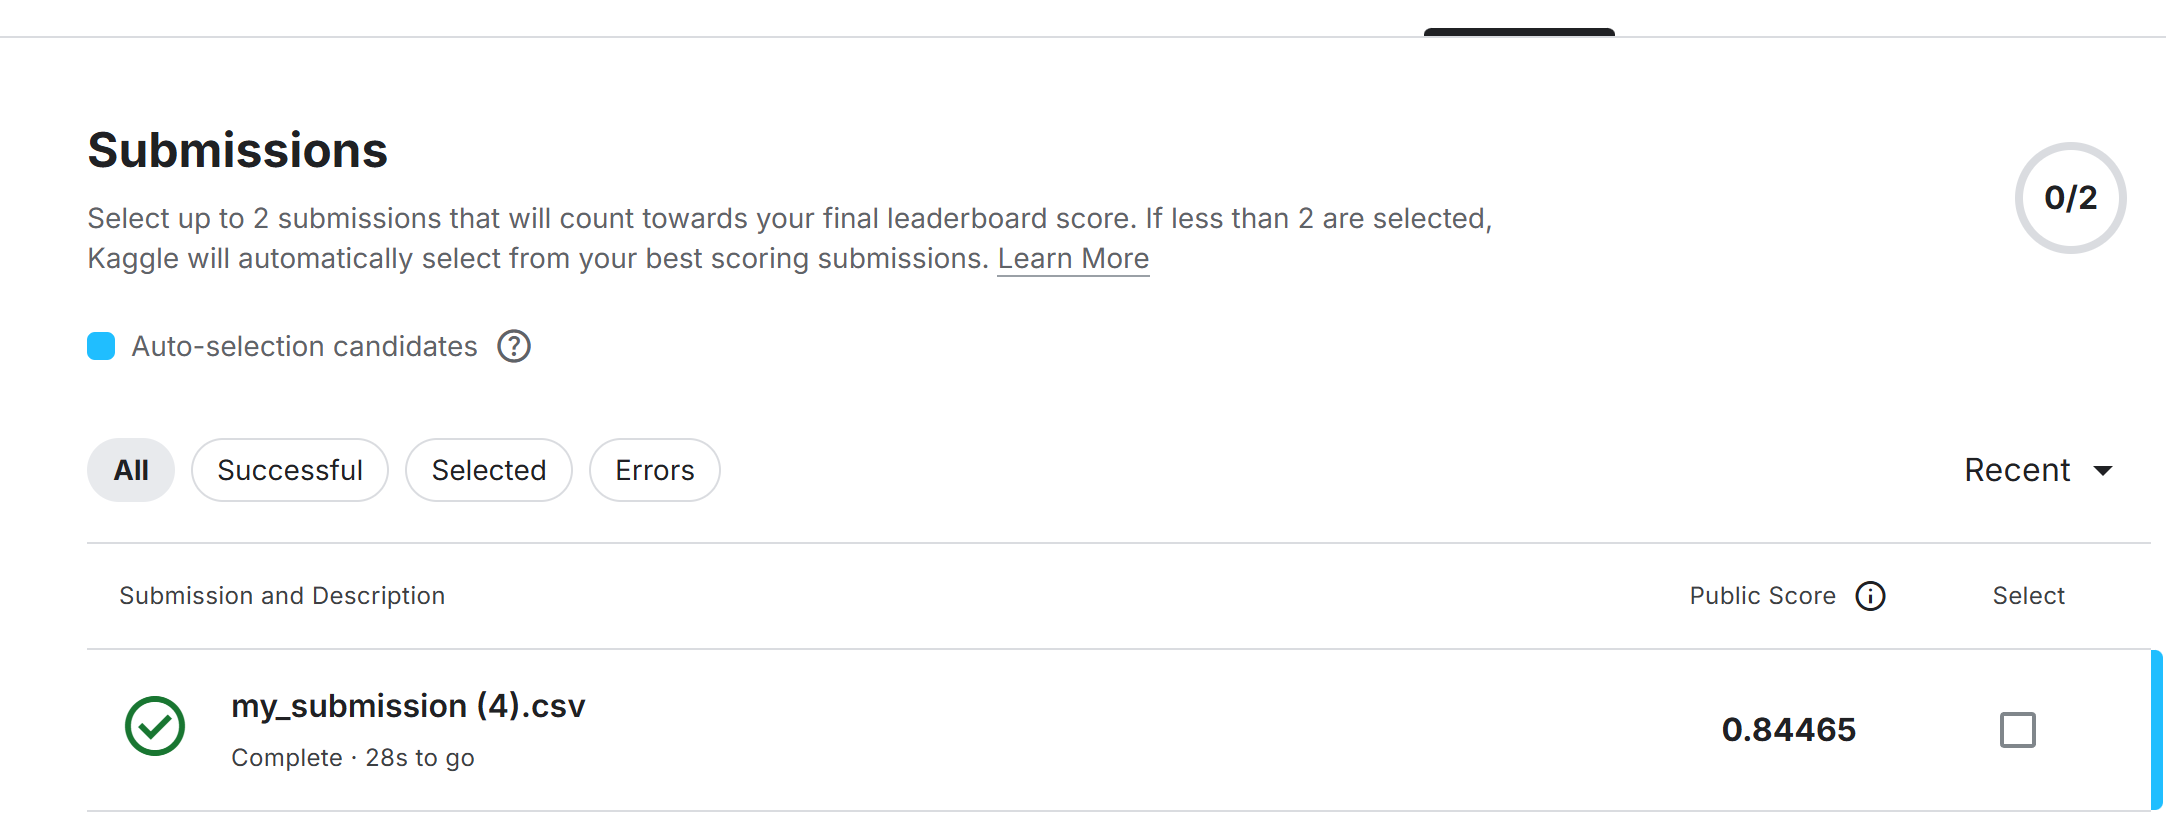